In [1]:
import sys
import os

# Get the current working directory
cwd = os.getcwd()
print(f"Current Working Directory: {cwd}")

# Define the path to the 'mapelite' folder
# We assume the notebook is running from the root 'Quality-Diversity-...' folder
mapelite_path = os.path.join(cwd, 'mapelite')

# Add it to the system path so Python can find config.py, utils.py, etc.
if mapelite_path not in sys.path:
    sys.path.append(mapelite_path)
    print(f"Added '{mapelite_path}' to sys.path")

Current Working Directory: d:\dev\Quality-Diversity-for-Racing-Track-Design
Added 'd:\dev\Quality-Diversity-for-Racing-Track-Design\mapelite' to sys.path


In [ ]:
import numpy as np
import random
import os

from ribs.archives import ProximityArchive
from ribs.schedulers import Scheduler

from emitter import CustomEmitter
from mapelite.qd_runner import QDRunner

d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from mapelite.config import (
    SOLUTION_DIM,
    BATCH_SIZE,
    NS_DIR,
    BUFFER_FILENAME,
    CHECKPOINT_DIR,
    STATS_FILENAME,
    ELITES_FILENAME,
    HEATMAP_DIR,
    GRIDPLOT_DIR,
    INVALID_SCORE,
    ITERATIONS
)

# --- Novelty Search specific config ---
checkpoint_dir = os.path.join(NS_DIR, CHECKPOINT_DIR)
heatmap_dir = os.path.join(NS_DIR, HEATMAP_DIR)
gridplot_dir = os.path.join(NS_DIR, GRIDPLOT_DIR)
stats_path = os.path.join(NS_DIR, STATS_FILENAME)
buffer_path = os.path.join(NS_DIR, BUFFER_FILENAME)

EMBEDDING_DIM = 32
DEFAULT_THRESHOLD = 5
SEED = 67
ELITES_OUTPUT = os.path.join(NS_DIR, ELITES_FILENAME)
ALGORITHM_LABEL = "Novelty Search (ProximityArchive + local competition)"

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)


In [ ]:
# --- Initialize directories ---
os.makedirs(NS_DIR, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(heatmap_dir, exist_ok=True)
os.makedirs(gridplot_dir, exist_ok=True)

# --- DASK SETUP ---
client, cluster, evaluator_future = QDRunner.setup_dask(BATCH_SIZE)

Setting up Dask LocalCluster...
Dask Dashboard link: http://127.0.0.1:8787/status
Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_latent32.pth...
Model loaded with latent_dim=32
Evaluator scattered to 10 Dask workers


In [ ]:
# --------------------------------------------------------------
# Resume from latest checkpoint if available,
# otherwise build archive from scratch
# --------------------------------------------------------------
state = QDRunner.resume_from_checkpoint(checkpoint_dir, stats_path)

if state["scheduler"] is not None:
    scheduler = state["scheduler"]
    archive   = state["archive"]
else:
    archive = ProximityArchive(
        solution_dim=SOLUTION_DIM,
        measure_dim=EMBEDDING_DIM,
        k_neighbors=15,
        novelty_threshold=DEFAULT_THRESHOLD,
        seed=SEED,
        local_competition=True
    )

    emitter = CustomEmitter(
        archive,
        solution_dim=SOLUTION_DIM,
        batch_size=BATCH_SIZE,
        bounds=[(0, 600)] * (SOLUTION_DIM - 1) + [(0, float("inf"))]
    )

    scheduler = Scheduler(archive, [emitter])
    print("Archive, emitter, and scheduler created.")

# --- Build the QDRunner ---
runner = QDRunner(
    scheduler=scheduler, archive=archive, client=client,
    evaluator_future=evaluator_future,
    checkpoint_dir=checkpoint_dir, heatmap_dir=heatmap_dir,
    gridplot_dir=gridplot_dir, stats_path=stats_path,
    buffer_path=buffer_path, seed=SEED,
)
runner.load_state(
    start_iter=state["start_iter"],
    global_best_score=state["global_best_score"],
    global_best_id=state["global_best_id"],
    stats=state["stats"],
)

[Resume] Loaded data/checkpoints/ns\checkpoint_1000.pkl, resuming from iteration 1001
[Resume] Resumed stats with 1000 entries


In [6]:
# print ribs version
import ribs
print(f"Ribs version: {ribs.__version__}")

Ribs version: 0.8.1


In [ ]:
# Run main loop
global_best_score, global_best_id, stats = runner.run(
    total_iters=ITERATIONS,
    start_iter=state["start_iter"],
)

[Buffer] No existing buffer found — starting empty.
[Buffer] Saved 0 entries to data/buffers/ns.json


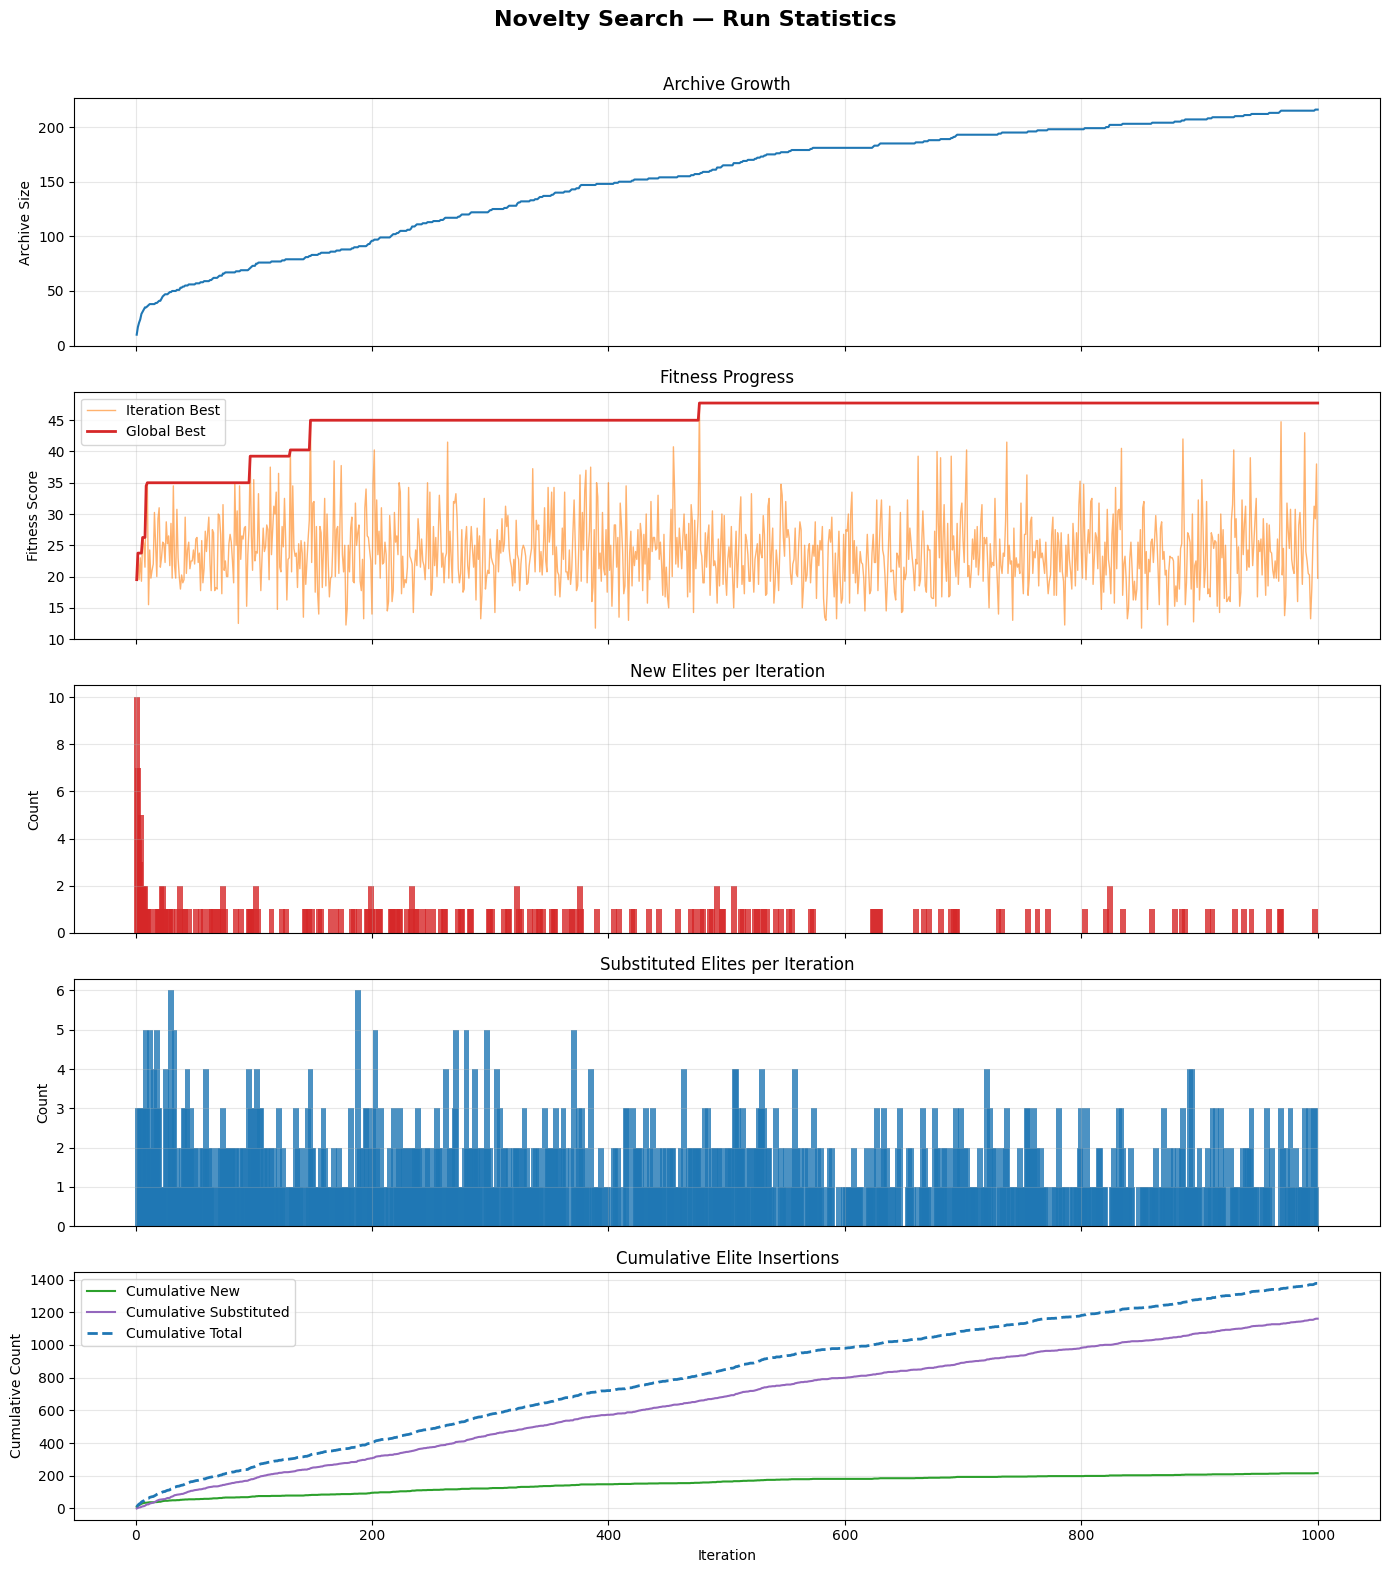


  Novelty Search Summary
  Total iterations:        1000
  Final archive size:      216
  Global best fitness:     47.7500
  Total new elites:        216
  Total substituted:       1161
  Avg new elites/iter:     0.22
  Avg substituted/iter:    1.16


In [ ]:
runner.visualizer.plot_stats(title="Novelty Search")

In [ ]:
runner.visualizer.export_elites(
    output_path=ELITES_OUTPUT,
    algorithm_label=ALGORITHM_LABEL,
    seed=SEED,
    global_best_score=global_best_score,
    global_best_id=global_best_id,
)

Skipped 1 elites with invalid fitness (INVALID_SCORE or NaN)
Saved 215 elites to data/elites/ns.json
  Best fitness:  47.7500 (ID=476.2427963091119)
  Worst fitness: 3.2500
  File size:     2350.0 KB
